## Análise exploratória do dataset WineQT

### Parte 1.1 - Carga dos dados e criação da coluna target

Nesta fase, os dados serão carregados para o dataframe dos scripts posteriores. Também será criada a coluna binária "target", a partir da coluna "quality", com base nas seguintes regras:
- Se quality ≥ 7, target terá valor 1;
- Se quality < 7, target terá valor 0.

In [1]:
# Importa as bibliotecas necessárias
import sys
import os

# Pega o diretório atual exato onde o notebook está rodando
diretorio_atual = os.getcwd()

# Descobre a raiz do projeto
if diretorio_atual.endswith('notebooks'):
    caminho_raiz = os.path.abspath(os.path.join(diretorio_atual, '..'))
else:
    # Caso o VS Code já esteja rodando a partir da raiz
    caminho_raiz = diretorio_atual

# Adiciona a raiz aos caminhos do Python
if caminho_raiz not in sys.path:
    sys.path.append(caminho_raiz)

print(f'Caminho raiz configurado para: {caminho_raiz}.')

# Importa a função de carga do dataset
from src.load import carregar_dataset
print('\nFunção de carregamento importada com sucesso.')

# Carrega o dataset e cria a coluna alvo
df = carregar_dataset('../data/WineQT.csv', 'quality')
print('\nDataset carregado e coluna alvo criada com sucesso.')
print(f'\nO dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.')

Caminho raiz configurado para: c:\z_FIAP\wine-quality-classification.

Função de carregamento importada com sucesso.

Dataset carregado e coluna alvo criada com sucesso.

O dataset possui 1143 linhas e 14 colunas.


### Parte 1.2 - Análise Exploratória dos Dados: Investigação da Distribuição das Variáveis

Nesta etapa, analisaremos a distribuição estatística de cada propriedade físico-química, com o objetivo de identificar:
1. **Assimetrias** - Verificar se os dados estão concentrados de um lado e possuem uma "cauda longa".
2. **Diferenças de Escala** - Como diferentes características possuem unidades de medida distintas (ex: porcentagem vs. mg/L), será necessário tratar essas escalas na fase de Pré-processamento, para não prejudicar o modelo de Machine Learning.

In [2]:
# Resumo estatístico das propriedades químicas

print('Resumo estatístico das propriedades químicas:')
print(df.drop(['quality', 'target'], axis=1, errors='ignore').describe().T)

Resumo estatístico das propriedades químicas:
                       count        mean         std      min        25%  \
fixed acidity         1143.0    8.311111    1.747595  4.60000    7.10000   
volatile acidity      1143.0    0.531339    0.179633  0.12000    0.39250   
citric acid           1143.0    0.268364    0.196686  0.00000    0.09000   
residual sugar        1143.0    2.532152    1.355917  0.90000    1.90000   
chlorides             1143.0    0.086933    0.047267  0.01200    0.07000   
free sulfur dioxide   1143.0   15.615486   10.250486  1.00000    7.00000   
total sulfur dioxide  1143.0   45.914698   32.782130  6.00000   21.00000   
density               1143.0    0.996730    0.001925  0.99007    0.99557   
pH                    1143.0    3.311015    0.156664  2.74000    3.20500   
sulphates             1143.0    0.657708    0.170399  0.33000    0.55000   
alcohol               1143.0   10.442111    1.082196  8.40000    9.50000   
Id                    1143.0  804.969379  

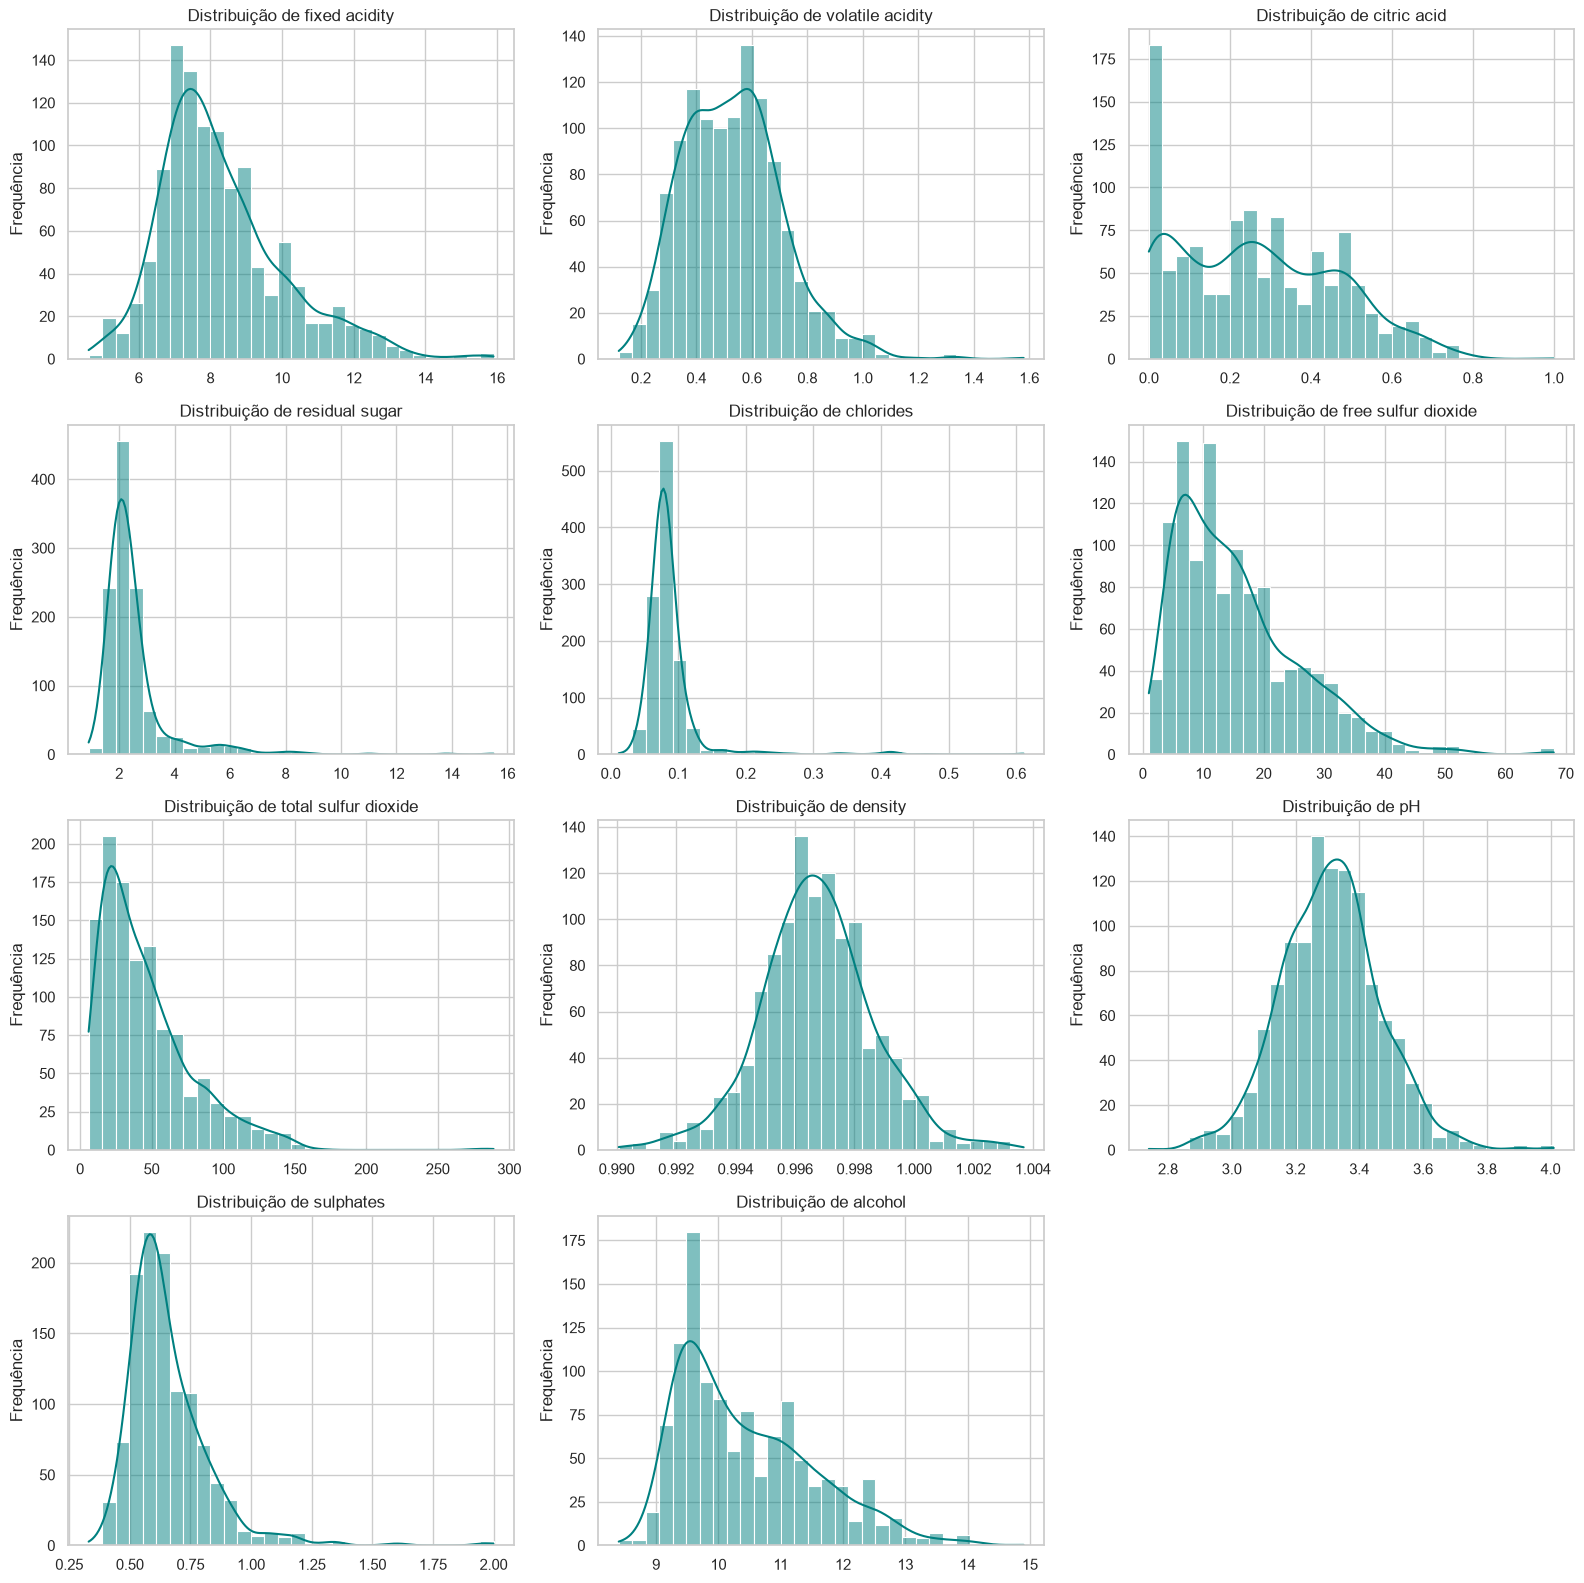

In [3]:
from src.plots import plot_distribuicoes
plot_distribuicoes(df, colunas_para_excluir=['Id', 'quality', 'target'])

### Insights da Distribuição

A análise das curvas de densidade e dos histogramas nos revela características fundamentais sobre a composição dos vinhos da base de dados, que guiarão nossas decisões de pré-processamento:

**1. Diferenças Críticas de Escala:**
* Observamos que as variáveis operam em grandezas completamente distintas. A `density` (densidade) varia em uma janela minúscula (ex: 0.990 a 1.003), enquanto o `total sulfur dioxide` (dióxido de enxofre total) atinge valores superiores a 150. 
* **Ação:** Como algoritmos de Machine Learning são sensíveis a distâncias matemáticas, será **necessário aplicar normalização ou padronização** (ex: `StandardScaler`), para evitar que variáveis com números maiores dominem o modelo injustamente.

**2. Assimetria Positiva (Cauda Longa à Direita):**
* Variáveis como `residual sugar` (açúcar residual), `chlorides` (cloretos) e `sulphates` (sulfatos) apresentam forte assimetria à direita. A grande maioria dos vinhos possui valores baixos, mas há uma "cauda" com poucos vinhos de valores altíssimos.
* **Ação:** Os valores altos não parecem ser sujos, mas sim valores característicos de nicho - como um vinho de sobremesa com muito açúcar. Portanto, **esses "outliers" não serão removidos**, e será necessário solucionar modelos que saibam lidar com essa distribuição natural.

**3. Padrões de Normalidade (Simetria):**
* Variáveis como `pH` e `density` apresentam distribuições quase perfeitamente normais. Isso indica uma alta consistência no processo de fermentação e produção da maioria das amostras, servindo como uma base estável para o aprendizado do algoritmo.



### Parte 1.3 - Análise Exploratória dos Dados: Correlação

Nesta fase, procuramos compreender as relações químicas que definem um vinho de **alta qualidade** (target igual a 1), analisando a correlação entre as variáveis físico-químicas e a qualidade.

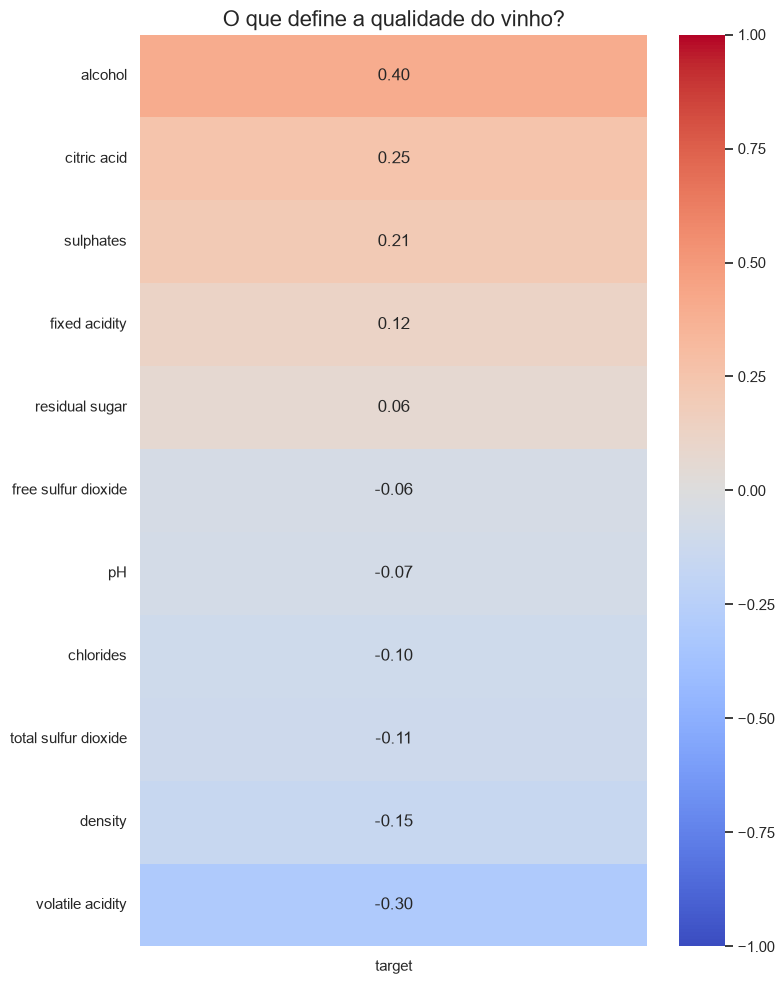

In [4]:
## Correlação entre as variáveis e a variável alvo

# Importa as funções visuais do módulo src
from src.plots import plot_correlacao_alvo

# Gera a Matriz de Correlação
plot_correlacao_alvo(df, 'target', ['Id', 'quality'], 'O que define a qualidade do vinho?')

### Insights da Correlação

Pela matriz acima, destacam-se as seguintes variáveis:
* **Correlação Positiva (`alcohol`):** Vinhos com maior teor alcoólico têm maior probabilidade de serem classificados como sendo de alta qualidade.
* **Correlação Negativa (`volatile acidity`):** Níveis elevados de acidez volátil estão fortemente associados a vinhos de baixa ou média qualidade.

### Parte 1.4 - Análise Exploratória dos Dados: Outliers e Valores Inconsistentes

Para garantir a integridade dos dados antes da modelagem, será preciso verificar três pontos importantes:
1. **Valores nulos:** Dados faltantes que podem quebrar o modelo.
2. **Linhas duplicadas:** Registros idênticos que podem causar viés.
3. **Quantificação de outliers:** Será utilizado o método do Intervalo Interquartil (IQR) para contar quantos registros fogem do padrão estatístico em cada propriedade.

In [5]:
## Verificação de Inconsistências (Nulos e Duplicados)

# 1. Checagem de valores nulos
print("1. Valores nulos por coluna:")
print(df.isnull().sum())

# 2. Verificação de linhas duplicadas
duplicadas = df.duplicated().sum()
print(f"\n2. Linhas duplicadas: {duplicadas}")

1. Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
target                  0
dtype: int64

2. Linhas duplicadas: 0


In [6]:
## Contagem de outliers
# Quantificação de Outliers via Regra do IQR

# Ignora as colunas alvo e IDs para esse cálculo
colunas_para_excluir = ['Id', 'quality', 'target']
colunas_iqr = df.drop(colunas_para_excluir, axis=1, errors='ignore')

# Calcula o IQR
Q1 = colunas_iqr.quantile(0.25)
Q3 = colunas_iqr.quantile(0.75)
IQR = Q3 - Q1

# Identifica e conta os outliers
outliers = ((colunas_iqr < (Q1 - 1.5 * IQR)) | (colunas_iqr > (Q3 + 1.5 * IQR))).sum()
print(f"\n3. Outliers por coluna:")
print(outliers)


3. Outliers por coluna:
fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
dtype: int64


### Insights dos Outliers e Valores Inconsistentes

**1. Valores Nulos:**

A base de dados é extremamente limpa, não possuindo valores faltantes nas medições químicas. Portanto, nenhuma técnica de inserção de dados será necessária.

**2. Linhas Duplicadas:**

Foi confirmada a ausência de registros duplicados. Isso indica uma integridade excelente na coleta, garantindo que cada linha representa uma amostra de vinho verdadeiramente única. Nenhuma etapa de remoção de linhas duplicadas é necessária.

**3. Outliers:**

O método IQR revelou um volume considerável de outliers em propriedades específicas. Como comprovado na análise de distribuição visual, tratam-se de variações naturais do produto, e não erros de medição ou digitação.

**Ação:** Os outliers não serão removidos para não perdermos informações vitais. Em vez disso, a normalização dos dados na etapa de pré-processamento garantirá que esses valores extremos não causem instabilidade nos modelos de Machine Learning.

### Parte 1.5 - Análise Exploratória dos Dados: Balanceamento das Classes

O passo final da Análise Exploratória dos Dados é avaliar a proporção entre as categorias da variável resposta. Em problemas de classificação binária, o **balanceamento das classes** é um dos fatores mais críticos para o sucesso do modelo de Machine Learning.

**Por que essa análise é importante?**
* **Risco de Viés:** Se o algoritmo for treinado com uma base onde uma classe domina quase totalmente os registros, ele tenderá a ficar "viciado" a prever sempre a classe majoritária, falhando em identificar os padrões da classe minoritária.
* **Escolha de Métricas:** A proporção das classes dita como o modelo será avaliado. Em cenários desbalanceados, a **Acurácia** pode ser afetada, exigindo o uso de métricas mais robustas como **F1-Score, Precisão e Recall**.
* **Estratégia de Modelagem:** O resultado deste gráfico dirá se será necessário aplicar técnicas de ajuste de pesos matemáticos ou reamostragem durante o pré-processamento.

Abaixo, é quantificada e exibida a distribuição exata de vinhos de alta qualidade em comparação aos demais na base de dados.

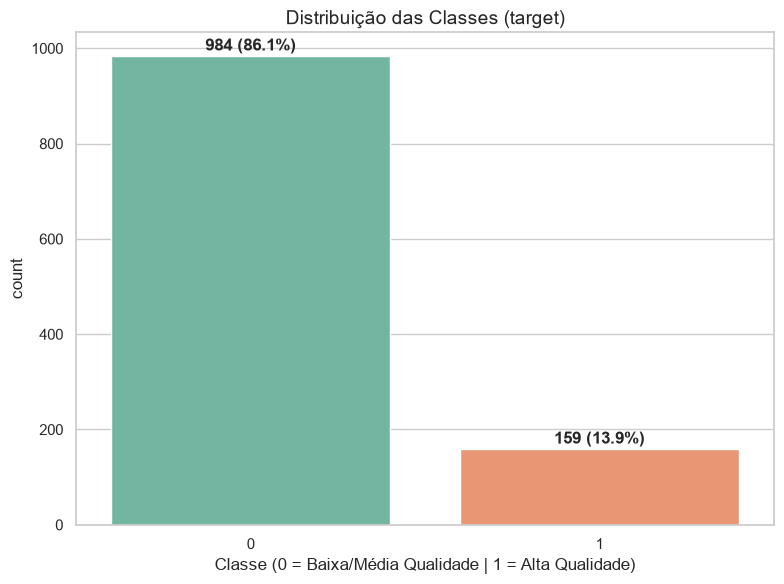

In [7]:
from src.plots import plot_balanceamento_classes

texto_legenda = "Classe (0 = Baixa/Média Qualidade | 1 = Alta Qualidade)"
plot_balanceamento_classes(df, col_alvo='target', rotulo_x=texto_legenda)

### Insights do Balanceamento

A distribuição entre as classes revela a verdadeira natureza do desafio de classificação e dita as regras para as próximas etapas do projeto:

**1. O Paradoxo da Acurácia:**

O gráfico demonstra um forte desbalanceamento: a imensa maioria dos vinhos concentra-se na classe 0, enquanto a classe 1 representa uma pequena fração. 

Se utilizássemos apenas a **acurácia** como métrica, um **modelo trivial** que previsse exclusivamente a classe 0 para todas as amostras alcançaria um desempenho aparentemente alto, falhando em aprender os padrões químicos reais dos vinhos. 

**2. Redefinição das Métricas de Sucesso:**

Devido ao desbalanceamento, a avaliação técnica não poderá ser baseada na **acurácia**. Direcionaremos a validação para as métricas focadas na Classe 1:
* **F1-Score** será a métrica principal de desempate entre os algoritmos.
* **Recall (Sensibilidade)** será essencial para medir a proporção de vinhos de alta qualidade que o modelo conseguiu efetivamente detectar.
* A **Precisão** é importante para garantir que, quando o modelo classificar um vinho como sendo de alta qualidade, haja um alto grau de certeza matemática.

**3. Plano de Ação para o Pré-Processamento e Modelagem:**

Para impedir que os algoritmos negligenciem a classe minoritária, aplicaremos as seguintes estratégias:
* **Divisão estratificada:** Na separação de dados de teste, utilizaremos o parâmetro `stratify` para garantir que a proporção exata de vinhos bons e comuns seja preservada tanto na base de treinamento quanto na de teste.
* **Ajuste de Pesos / Reamostragem:** Na etapa de modelagem, serão explorados hiperparâmetros como `class_weight='balanced'` ou técnicas de *oversampling* para penalizar o algoritmo matematicamente sempre que ele errar a predição de um vinho da classe 1.



##